In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import xarrams as xrr

from metpy.units import units
import metpy.constants as mpconstants
import metpy.calc as mpc

,z,PS,TS,RTS,US,VS,dewpoint
0,0,1000.000000,26.850000,49.263542,0.000000,0.0,15.305623
1,10,998.868970,26.759102,49.471100,0.012531,0.0,15.288007
2,20,997.738881,26.670504,49.672982,0.025063,0.0,15.270389
3,30,996.609740,26.583068,49.872442,0.037594,0.0,15.252767
4,40,995.481548,26.496473,50.070379,0.050125,0.0,15.235143
5,50,994.354310,26.410551,50.267264,0.062657,0.0,15.217516
6,60,993.228026,26.325197,50.463388,0.075188,0.0,15.199887
7,70,992.102698,26.240335,50.658955,0.087719,0.0,15.182255
8,80,990.978327,26.155911,50.854114,0.100251,0.0,15.164620
9,90,989.854914,26.071882,51.048981,0.112782,0.0,15.146983


,z,PS,TS,RTS,US,VS,dewpoint
2271,22710,37.768905,-53.335509,25.021640,5.0,0.0,-64.219003
2272,22720,37.710220,-53.332370,25.021682,5.0,0.0,-64.216228
2273,22730,37.651626,-53.329229,25.021724,5.0,0.0,-64.213452
2274,22740,37.593124,-53.326087,25.021766,5.0,0.0,-64.210674
2275,22750,37.534714,-53.322943,25.021808,5.0,0.0,-64.207896
2276,22760,37.476396,-53.319798,25.021850,5.0,0.0,-64.205116
2277,22770,37.418169,-53.316651,25.021892,5.0,0.0,-64.202334
2278,22780,37.360034,-53.313503,25.021934,5.0,0.0,-64.199552
2279,22790,37.301989,-53.310354,25.021977,5.0,0.0,-64.196768
2280,22800,37.244036,-53.307203,25.022019,5.0,0.0,-64.193983


/autofs/nccsopen-svm1_home/cmdavis4/projects/carlee/xarrams/xarrams/soundings.py:198: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  skewt.ax.set_yticklabels(new_labels)


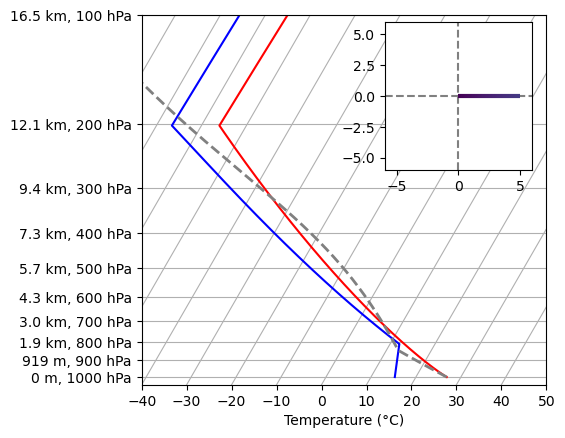

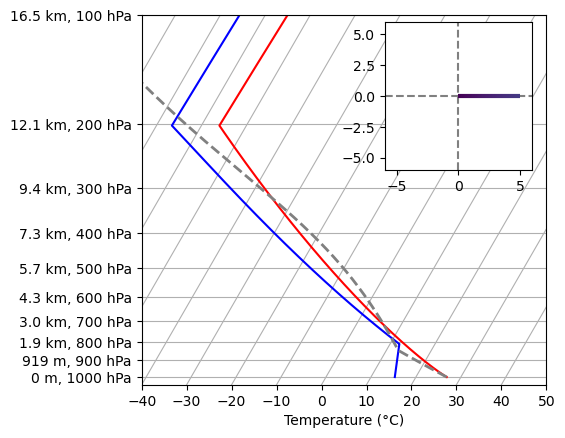

In [2]:
generated_sounding = xrr.soundings.wk84_sounding(
    U_s=5 * units("m/s"), q_v0=11 * units("g/kg"), p_sfc=100000 * units("Pa")
)
generated_sounding["dewpoint"] = mpc.dewpoint_from_relative_humidity(
    temperature=generated_sounding["TS"].values * units("degC"),
    relative_humidity=generated_sounding["RTS"].values * units("percent"),
)
display(generated_sounding.head(30))
display(generated_sounding.tail(30))
xrr.plot_sounding(generated_sounding, barbs=False)

In [3]:
cm1_sounding_ds = xr.open_dataset("../data/cm1_wk_sounding_qv-11.nc")
cm1_sounding_ds

<xarray.Dataset> Size: 2kB
Dimensions:  (zh: 108)
Coordinates:
  * zh       (zh) float32 432B 62.5 187.8 313.8 ... 1.768e+04 1.789e+04
    time     timedelta64[ns] 8B ...
Data variables:
    th       (zh) float32 432B ...
    prs      (zh) float32 432B ...
    qv       (zh) float32 432B ...
Attributes: (12/71)
    CM1 version:    cm1r21.1
    Conventions:    CF-1.7
    missing_value:  -999999.9
    x_units:        meters
    x_label:        x
    y_units:        meters
    ...             ...
    cgt1:           1.8785591
    cgt2:           -1.2577622
    cgt3:           0.37920308
    dgt1:           2.0090303
    dgt2:           -3.02066
    dgt3:           1.0116295

/autofs/nccsopen-svm1_home/cmdavis4/projects/carlee/xarrams/xarrams/soundings.py:198: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  skewt.ax.set_yticklabels(new_labels)


,zh,th,prs,qv,time,PS,TS,dewpoint,z,US,VS
0,62.500000,300.064911,99296.929688,0.011000,0 days,992.969299,26.310629,15.195836,62.500000,0,0
1,187.821960,300.296539,97893.609375,0.011000,0 days,978.936096,25.325515,14.974638,187.821960,0,0
2,313.789490,300.510101,96498.296875,0.011000,0 days,964.982971,24.315167,14.751920,313.789490,0,0
3,440.405884,300.695068,95111.195312,0.011000,0 days,951.111938,23.269501,14.527685,440.405884,0,0
4,567.674561,300.948547,93732.515625,0.011000,0 days,937.325134,22.284288,14.301941,567.674561,0,0
...,...,...,...,...,...,...,...,...,...,...,...
103,17034.109375,431.932465,9167.658203,0.000062,0 days,91.676582,-54.918091,-65.578119,17034.109375,0,0
104,17246.855469,436.160858,8867.515625,0.000064,0 days,88.675156,-54.867622,-65.531043,17246.855469,0,0
105,17460.699219,440.453827,8575.793945,0.000067,0 days,85.757942,-54.815869,-65.483264,17460.699219,0,0
106,17675.644531,444.809998,8292.310547,0.000069,0 days,82.923103,-54.764049,-65.434737,17675.644531,0,0


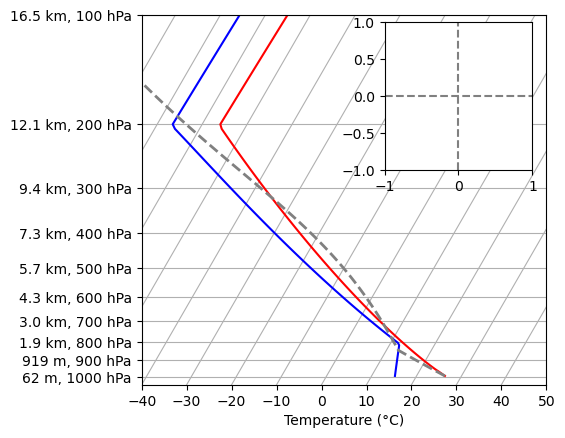

In [4]:
cm1_sounding_df = cm1_sounding_ds.to_pandas().reset_index()
cm1_sounding_df["PS"] = cm1_sounding_ds["prs"].values / 100.0

cm1_sounding_df["TS"] = (
    mpc.temperature_from_potential_temperature(
        pressure=cm1_sounding_df["PS"].values * units("hPa"),
        potential_temperature=cm1_sounding_df["th"].values * units("K"),
    )
    .to("degC")
    .magnitude
)

vp = mpc.vapor_pressure(
    cm1_sounding_df["PS"].values * units("hPa"),
    cm1_sounding_df["qv"].values * units("kg/kg"),
)
cm1_sounding_df["dewpoint"] = mpc.dewpoint(vp).to("degC").magnitude
cm1_sounding_df["z"] = cm1_sounding_ds["zh"].values
cm1_sounding_df["US"] = 0
cm1_sounding_df["VS"] = 0

xrr.plot_sounding(cm1_sounding_df, barbs=False)

display(cm1_sounding_df)

484.6418200565035
485.24635463488113


,z,PS_cm1,PS_g,RTS_cm1,RTS_g,TS_cm1,TS_g,dewpoint_cm1,dewpoint_g,parcel_T_cm1,parcel_T_g,parcel_theta_cm1,parcel_theta_g,qv_cm1,qv_g,theta_calc,theta_cm1,theta_g
0,62.500000,992.969299,992.946694,50.464983,50.483600,26.310629,26.303981,15.195836,15.195479,299.460629,299.453981,300.064911,300.060201,10.993664,10.993662,300.060150,300.064911,300.060201
1,187.821960,978.936096,978.916220,52.737418,52.924113,25.325515,25.265664,14.974638,14.974320,298.245292,298.238880,300.064911,300.060201,10.993792,10.993791,300.238068,300.296539,300.238064
2,313.789490,964.982971,964.965902,55.213048,55.406872,24.315167,24.256314,14.751920,14.751642,297.024488,297.018324,300.064911,300.060201,10.993916,10.993914,300.452148,300.510101,300.452164
3,440.405884,951.111938,951.097681,57.948217,57.966731,23.269501,23.263955,14.527685,14.527451,295.798304,295.792394,300.064911,300.060201,10.994035,10.994034,300.690735,300.695068,300.690730
4,567.674561,937.325134,937.313545,60.619132,60.621767,22.284288,22.283367,14.301941,14.301747,294.566842,294.561178,300.064911,300.060201,10.994150,10.994148,300.948669,300.948547,300.948672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,17034.109375,91.676582,91.595889,25.982276,25.850753,-54.918091,-54.905086,-65.578119,-65.604463,167.717459,167.672620,331.952443,331.947202,0.063627,0.063460,431.999298,431.932465,432.066897
104,17246.855469,88.675156,88.594660,25.988695,25.848258,-54.867622,-54.853262,-65.531043,-65.558765,166.129966,166.084242,331.952534,331.947292,0.066196,0.066011,436.231598,436.160858,436.302747
105,17460.699219,85.757942,85.677704,25.993562,25.845744,-54.815869,-54.800666,-65.483264,-65.512384,164.549785,164.503184,331.952601,331.947359,0.068886,0.068683,440.527527,440.453827,440.602320
106,17675.644531,82.923103,82.843202,26.000812,25.843209,-54.764049,-54.747283,-65.434737,-65.465306,162.976991,162.929534,331.952649,331.947407,0.071704,0.071481,444.888184,444.809998,444.966689


Text(0.5, 1.0, 'Dewpoint deviation from CM1')

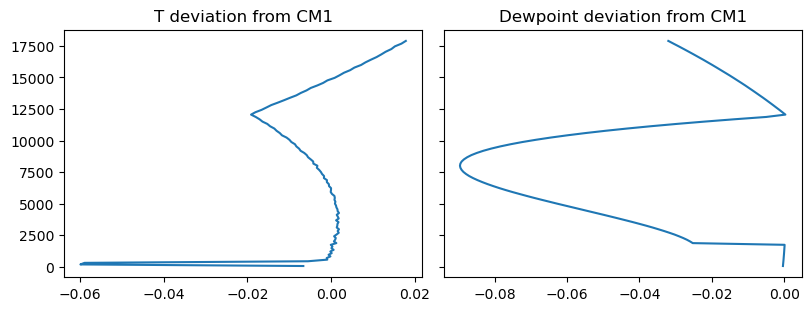

In [5]:
# Create a comparison
# Interpolate our sounding to the levels in CM1
basic_state_vars = ["z", "TS", "PS", "dewpoint"]
# generated_sounding_interped =
generated_sounding_interped = pd.DataFrame({"z": cm1_sounding_df["z"].values})
interp_cols = [c for c in basic_state_vars if c != "z"]
for c in interp_cols:
    generated_sounding_interped[c] = np.interp(
        generated_sounding_interped["z"].values,
        generated_sounding["z"].values,
        generated_sounding[c].values,
    )

to_merge = [
    generated_sounding_interped[basic_state_vars],
    cm1_sounding_df[basic_state_vars],
]

for df in to_merge:
    df["theta"] = (
        mpc.potential_temperature(
            pressure=df["PS"].values * units("hPa"),
            temperature=df["TS"].values * units("degC"),
        )
        .to("K")
        .magnitude
    )
    df["RTS"] = (
        mpc.relative_humidity_from_dewpoint(
            temperature=df["TS"].values * units("degC"),
            dewpoint=df["dewpoint"].values * units("degC"),
        )
        .to("percent")
        .magnitude
    )
    df["qv"] = (
        mpc.mixing_ratio_from_relative_humidity(
            pressure=df["PS"].values * units("hPa"),
            temperature=df["TS"].values * units("degC"),
            relative_humidity=df["RTS"].values * units("percent"),
        )
        .to("g/kg")
        .magnitude
    )
    df["parcel_T"] = mpc.parcel_profile(
        pressure=df["PS"].values * units("hPa"),
        temperature=df["TS"].values[0] * units("degC"),
        dewpoint=df["dewpoint"].values[0] * units("degC"),
    )
    df["parcel_theta"] = mpc.potential_temperature(
        pressure=df["PS"].values * units("hPa"),
        temperature=df["parcel_T"].values * units("K"),
    )
    integrand = (df["parcel_theta"] - df["theta"]) / df["theta"]
    # Restrict to positive-buoyancy region (the "positive area on a skew-T")
    positive = np.where(integrand > 0, integrand, 0.0)

    integrand_da = xr.DataArray(
        # ((parcel_path_theta.to('K').magnitude - sounding['THETA']) / sounding['THETA']),
        integrand,
        dims=["z"],
        coords={"z": df["z"].values},
    )
    g = mpconstants.g.to("m/s^2").magnitude
    B = (integrand_da.where(integrand_da > 0, 0).integrate("z") * g).item()
    print(B)

merged_df = pd.merge(*to_merge, on="z", suffixes=("_g", "_cm1"))

theta_0 = 300
theta_tr = 343
T_tr = 213
z_tr = 12000

merged_df["theta_calc"] = np.where(
    df["z"] <= z_tr,
    (theta_0 + (theta_tr - theta_0) * (df["z"] / z_tr) ** (5 / 4)),
    theta_tr * np.exp((9.8 / (1004 * T_tr)) * (df["z"] - z_tr)),
)

merged_df = merged_df[["z"] + sorted([x for x in merged_df.columns if x != "z"])]
display(merged_df)

fig, axs = plt.subplots(ncols=2, figsize=(8, 3), layout="constrained", sharey=True)

axs[0].plot(
    merged_df["TS_g"] - merged_df["TS_cm1"],
    merged_df["z"].values,
)
axs[0].set_title("T deviation from CM1")

axs[1].plot(
    merged_df["dewpoint_g"] - merged_df["dewpoint_cm1"],
    merged_df["z"].values,
)
axs[1].set_title("Dewpoint deviation from CM1")